## Step: Creating Healthcare Monitoring Database

### Objective
To build a structured health monitoring database that stores user health metrics,
medication schedules, and wellness goals.

### Why This Step Is Important
The healthcare AI agent must track health data over time to provide meaningful
insights and recommendations.

This database will store:

- Health metrics (weight, blood pressure, glucose, etc.)
- Medication tracking
- Wellness goals

This enables the system to perform health analytics and predictive modeling.

In [ ]:
import sqlite3

conn = sqlite3.connect("health_monitoring.db")
cursor = conn.cursor()

# Users table
cursor.execute("""
CREATE TABLE IF NOT EXISTS users (
    user_id INTEGER PRIMARY KEY AUTOINCREMENT,
    name TEXT,
    age INTEGER,
    gender TEXT
)
""")

# Health metrics table
cursor.execute("""
CREATE TABLE IF NOT EXISTS health_metrics (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    user_id INTEGER,
    date TEXT,
    weight REAL,
    blood_pressure TEXT,
    glucose REAL,
    heart_rate INTEGER,
    steps INTEGER,
    sleep_hours REAL
)
""")

# Medications table
cursor.execute("""
CREATE TABLE IF NOT EXISTS medications (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    user_id INTEGER,
    medicine_name TEXT,
    dosage TEXT,
    time TEXT,
    taken_status TEXT
)
""")

# Wellness goals
cursor.execute("""
CREATE TABLE IF NOT EXISTS goals (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    user_id INTEGER,
    goal_type TEXT,
    target_value REAL,
    current_progress REAL
)
""")

conn.commit()
conn.close()

print("Healthcare database created successfully")

Healthcare database created successfully


## Step: Recording User Health Metrics

### Objective
To allow the system to store daily health data such as weight, blood pressure,
glucose level, heart rate, steps, and sleep hours.

### Why This Step Is Important
Tracking health metrics over time enables the healthcare AI agent to:

- detect health patterns
- generate wellness insights
- predict potential health risks
- provide personalized health recommendations

In [ ]:
import sqlite3
from datetime import datetime

def add_health_metrics(user_id, weight, blood_pressure, glucose, heart_rate, steps, sleep_hours):

    conn = sqlite3.connect("health_monitoring.db")
    cursor = conn.cursor()

    cursor.execute("""
    INSERT INTO health_metrics (
        user_id,
        date,
        weight,
        blood_pressure,
        glucose,
        heart_rate,
        steps,
        sleep_hours
    )
    VALUES (?, ?, ?, ?, ?, ?, ?, ?)
    """, (
        user_id,
        datetime.now().strftime("%Y-%m-%d"),
        weight,
        blood_pressure,
        glucose,
        heart_rate,
        steps,
        sleep_hours
    ))

    conn.commit()
    conn.close()
    print("Health metrics added successfully")



In [ ]:
add_health_metrics(
    user_id=1,
    weight=72,
    blood_pressure="120/80",
    glucose=95,
    heart_rate=72,
    steps=6500,
    sleep_hours=7
)

Health metrics added successfully


In [ ]:
conn = sqlite3.connect("health_monitoring.db")
cursor = conn.cursor()

cursor.execute("SELECT * FROM health_metrics")
rows = cursor.fetchall()

for row in rows:
    print(row)

conn.close()

(1, 1, '2026-03-08', 72.0, '120/80', 95.0, 72, 6500, 7.0)


## Step: Implementing Smart Medication Tracking

### Objective
To build an intelligent medication tracking system that records medicine
schedules, monitors adherence, and provides AI-driven health insights.

### Why This Step Is Important
Medication adherence is a critical factor in managing chronic diseases.
This module allows the healthcare AI agent to:

- track medicine schedules
- monitor missed doses
- analyze medication patterns
- generate personalized health insights

In [ ]:
import sqlite3

def add_medication(user_id, medicine_name, dosage, time):

    conn = sqlite3.connect("health_monitoring.db")
    cursor = conn.cursor()

    cursor.execute("""
    INSERT INTO medications (
        user_id,
        medicine_name,
        dosage,
        time,
        taken_status
    )
    VALUES (?, ?, ?, ?, ?)
    """, (
        user_id,
        medicine_name,
        dosage,
        time,
        "pending"
    ))

    conn.commit()
    conn.close()

    print("Medication added successfully")

In [ ]:
add_medication(
    user_id=1,
    medicine_name="Metformin",
    dosage="500mg",
    time="08:00"
)

Medication added successfully


In [ ]:
def mark_medication_taken(medication_id):

    conn = sqlite3.connect("health_monitoring.db")
    cursor = conn.cursor()

    cursor.execute("""
    UPDATE medications
    SET taken_status = 'taken'
    WHERE id = ?
    """, (medication_id,))

    conn.commit()
    conn.close()

    print("Medication marked as taken")

In [ ]:
mark_medication_taken(1)

Medication marked as taken


In [ ]:
def view_medications(user_id):

    conn = sqlite3.connect("health_monitoring.db")
    cursor = conn.cursor()

    cursor.execute("""
    SELECT * FROM medications
    WHERE user_id = ?
    """, (user_id,))

    rows = cursor.fetchall()

    for row in rows:
        print(row)

    conn.close()

In [ ]:
view_medications(1)

(1, 1, 'Metformin', '500mg', '08:00', 'taken')


# Model Training

## Step: Training Health Risk Prediction Models

### Objective
To train machine learning models capable of predicting potential health risks
based on user health metrics.

### Why This Step Is Important
Predictive analytics allows the healthcare AI agent to identify potential
health risks early and provide personalized recommendations.

The system will predict:

- Diabetes risk
- Hypertension risk
- Obesity risk

## Install Libraries

In [ ]:
!pip install scikit-learn pandas numpy

# Step 1: Import Required Libraries

In this step we import all necessary libraries for:
- data manipulation
- visualization
- machine learning
- model evaluation

In [34]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import accuracy_score

# Step 2: Load Diabetes Dataset

The dataset contains medical attributes used to predict
whether a patient has diabetes.

In [35]:
import pandas as pd

url = "https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv"

df = pd.read_csv(url)

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# Step 3: Dataset Overview

We inspect the dataset structure and check for missing values.

In [36]:
print(df.shape)


(768, 9)


In [37]:
print(df.columns)


Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


# Step 4: Checking Missing Values

In [39]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [41]:
cols = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]
df[cols] =df[cols].replace(0,np.nan)
df.isnull().sum()

,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [42]:
df.fillna(df.median(), inplace=True)
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


# Step 5: Exploratory Data Analysis

Visualizing feature relationships and distribution.

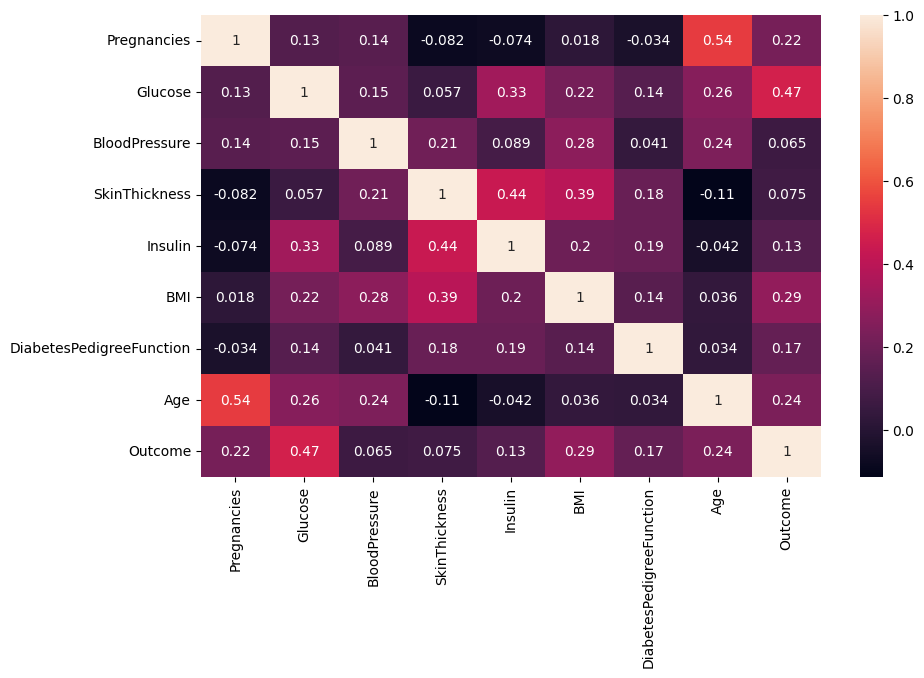

In [40]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True)
plt.show()

<Axes: xlabel='Glucose', ylabel='Count'>

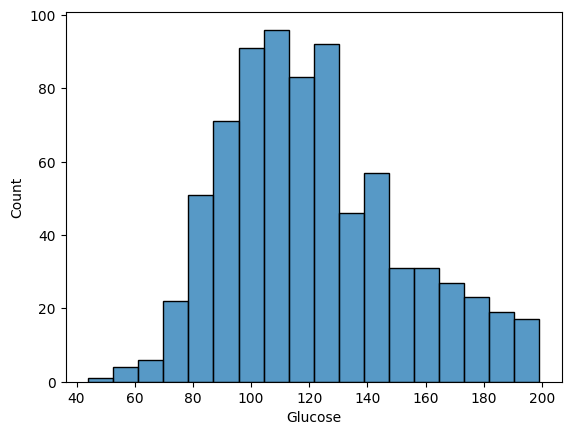

In [49]:
sns.histplot(df["Glucose"])

<Axes: xlabel='Outcome', ylabel='BMI'>

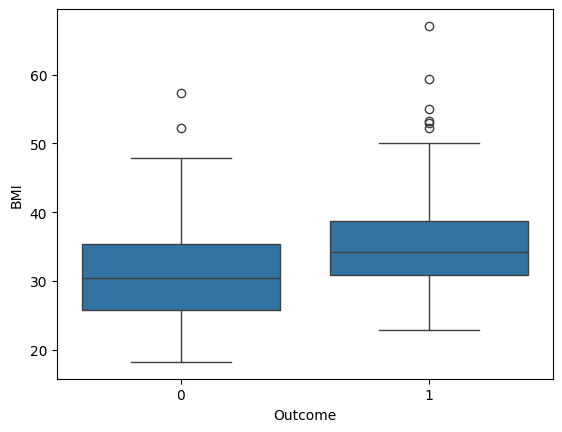

In [50]:
sns.boxplot(x=df["Outcome"], y=df["BMI"])

# Step 6: Defining Features and Target Variable

In [43]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# Step 7: Splitting Dataset


In [51]:
train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

[     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
 353            1     90.0           62.0           12.0     43.0  27.2   
 711            5    126.0           78.0           27.0     22.0  29.6   
 373            2    105.0           58.0           40.0     94.0  34.9   
 46             1    146.0           56.0           29.0    125.0  29.7   
 682            0     95.0           64.0           39.0    105.0  44.6   
 ..           ...      ...            ...            ...      ...   ...   
 451            2    134.0           70.0           29.0    125.0  28.9   
 113            4     76.0           62.0           29.0    125.0  34.0   
 556            1     97.0           70.0           40.0    125.0  38.1   
 667           10    111.0           70.0           27.0    125.0  27.5   
 107            4    144.0           58.0           28.0    140.0  29.5   
 
      DiabetesPedigreeFunction  Age  
 353                     0.580   24  
 711                  

In [ ]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# Step 7: Splitting Dataset


In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Step 8: Feature Scaling

Scaling ensures that features contribute equally
to the machine learning model.

In [54]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 9: Training Multiple ML Models

We evaluate multiple models and compare their accuracy.

In [55]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "Gradient Boosting": GradientBoostingClassifier()
}

results = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)

    results[name] = acc

In [56]:
for model, acc in results.items():
    print(model, ":", acc)

Logistic Regression : 0.7077922077922078
Random Forest : 0.7532467532467533
SVM : 0.7402597402597403
Gradient Boosting : 0.7792207792207793


## Step 11: Selecting Best Model

Based on accuracy comparison we select the best performing model.

In [60]:
best_model = models["Gradient Boosting"]

best_model.fit(X_train, y_train)

GradientBoostingClassifier()

### Evaluate Final Model

In [61]:
preds = best_model.predict(X_test)

accuracy = accuracy_score(y_test, preds)

print("Final Model Accuracy:", accuracy)

Final Model Accuracy: 0.7597402597402597


## Step 13: Saving Model and Scaler

We save the trained model and scaler so they can be reused
by the Healthcare AI Agent.

In [62]:
import joblib

joblib.dump(best_model, "health_risk_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model and scaler saved successfully")

Model and scaler saved successfully


## Step: Creating Health Risk Prediction Function

### Objective
To create a function that takes user health metrics as input
and predicts the probability of diabetes risk.

### Why This Step Is Important
This function will allow the healthcare AI agent to perform
real-time health risk prediction and generate personalized
health recommendations.

## Load Model for Prediction

In [63]:
import joblib

model = joblib.load("health_risk_model.pkl")
scaler = joblib.load("scaler.pkl")

## Step 15: Creating Diabetes Risk Prediction Function

In [64]:
import pandas as pd

def predict_diabetes(pregnancies, glucose, blood_pressure, skin_thickness,
                     insulin, bmi, diabetes_pedigree, age):

    data = pd.DataFrame([{
        "Pregnancies": pregnancies,
        "Glucose": glucose,
        "BloodPressure": blood_pressure,
        "SkinThickness": skin_thickness,
        "Insulin": insulin,
        "BMI": bmi,
        "DiabetesPedigreeFunction": diabetes_pedigree,
        "Age": age
    }])

    data_scaled = scaler.transform(data)

    prediction = model.predict(data_scaled)[0]

    if prediction == 1:
        return "High Diabetes Risk"
    else:
        return "Low Diabetes Risk"

## Test Prediction

In [65]:
predict_diabetes(
    pregnancies=2,
    glucose=130,
    blood_pressure=85,
    skin_thickness=20,
    insulin=85,
    bmi=28,
    diabetes_pedigree=0.5,
    age=45
)

'Low Diabetes Risk'

# Step 8: Feature Scaling

Scaling ensures that features contribute equally
to the machine learning model.

In [45]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 9: Training Multiple ML Models

We evaluate multiple models and compare their accuracy.

In [46]:
models = {

"Logistic Regression": LogisticRegression(),
"Random Forest": RandomForestClassifier(),
"SVM": SVC(),
"Gradient Boosting": GradientBoostingClassifier()

}

for name, model in models.items():

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)

    print(name, ":", acc)

Logistic Regression : 0.7532467532467533
Random Forest : 0.7467532467532467
SVM : 0.7467532467532467
Gradient Boosting : 0.7597402597402597


In [47]:
!pip install xgboost

In [48]:
from xgboost import XGBClassifier

model = XGBClassifier()

model.fit(X_train, y_train)

pred = model.predict(X_test)

accuracy_score(y_test, pred)

0.7142857142857143

### Evaluate Model

In [ ]:
from sklearn.metrics import accuracy_score

preds = model.predict(X_test)

accuracy = accuracy_score(y_test, preds)

print("Model accuracy:", accuracy)

Model accuracy: 0.7337662337662337


### Save Model

In [ ]:
import joblib

joblib.dump(model, "diabetes_model.pkl")

print("Model saved successfully")

Model saved successfully


## Step: Creating Health Risk Prediction Function

### Objective
To create a function that takes user health metrics as input
and predicts the probability of diabetes risk.

### Why This Step Is Important
This function will allow the healthcare AI agent to perform
real-time health risk prediction and generate personalized
health recommendations.

In [52]:
model = joblib.load("health_risk_model.pkl")
scaler = joblib.load("scaler.pkl")

def predict_diabetes(pregnancies, glucose, blood_pressure, skin_thickness,
                     insulin, bmi, diabetes_pedigree, age):

    data = pd.DataFrame([{
        "Pregnancies": pregnancies,
        "Glucose": glucose,
        "BloodPressure": blood_pressure,
        "SkinThickness": skin_thickness,
        "Insulin": insulin,
        "BMI": bmi,
        "DiabetesPedigreeFunction": diabetes_pedigree,
        "Age": age
    }])

    data_scaled = scaler.transform(data)

    prediction = model.predict(data_scaled)[0]

    if prediction == 1:
        return "High Diabetes Risk"
    else:
        return "Low Diabetes Risk"

FileNotFoundError: [Errno 2] No such file or directory: 'scaler.pkl'

In [ ]:
predict_diabetes(
    pregnancies=2,
    glucose=130,
    blood_pressure=85,
    skin_thickness=20,
    insulin=85,
    bmi=28,
    diabetes_pedigree=0.5,
    age=45
)

'Low Diabetes Risk'